# Load Libraries

In [2]:
import pandas as pd

# Load Orthogroup Data

In [5]:
#Load orthogroups data.
orthogroups_file = './01-MMUS-DMEL/Orthogroups/Orthogroups.tsv'
orthogroups = pd.read_csv(orthogroups_file, sep = '\t')

In [6]:
orthogroups.head()

,Orthogroup,Dmelanogaster.pep,Hglaberrima.2023.pep,Mmusculus.pep
0,OG0000000,sp|M9PBE2|HAKAI_DROME E3 ubiquitin-protein lig...,"41285_t, 62235_t, ACBD5_jg2130.t1, AGAP3_jg171...",sp|P53808|PPCT_MOUSE Phosphatidylcholine trans...
1,OG0000001,NaN,"AGRIN_jg2322.t1, BMI1A_jg43079.t1, EAF6_jg2145...",NaN
2,OG0000002,NaN,"FCNV2_jg22908.t1, GABR2_jg3849.t1, HYAL_jg1390...",NaN
3,OG0000003,NaN,"ACHA_jg51830.t1, AP5S1_jg8625.t1, ARSG_jg11658...",sp|Q8VIG3|RSPH1_MOUSE Radial spoke head 1 homo...
4,OG0000004,NaN,"AKR1_jg27823.t1, DEN5B_jg51746.t1, DPOL_jg1057...",NaN


# Filtering for Species of interes

In [7]:
species_of_interest = ['Dmelanogaster.pep', 'Hglaberrima.2023.pep', "Mmusculus.pep"]
filtered_orthogroups = orthogroups.loc[:, ['Orthogroup'] + species_of_interest]

# Calculate size of each gene family

In [8]:
for species in species_of_interest:
    filtered_orthogroups[species + '_Genes'] = filtered_orthogroups[species].str.split(',')
    filtered_orthogroups[species + '_Family_Size'] = filtered_orthogroups[species + '_Genes'].apply(lambda x: len(x) if isinstance(x, list) else 0)

In [9]:
filtered_orthogroups.head()

,Orthogroup,Dmelanogaster.pep,Hglaberrima.2023.pep,Mmusculus.pep,Dmelanogaster.pep_Genes,Dmelanogaster.pep_Family_Size,Hglaberrima.2023.pep_Genes,Hglaberrima.2023.pep_Family_Size,Mmusculus.pep_Genes,Mmusculus.pep_Family_Size
0,OG0000000,sp|M9PBE2|HAKAI_DROME E3 ubiquitin-protein lig...,"41285_t, 62235_t, ACBD5_jg2130.t1, AGAP3_jg171...",sp|P53808|PPCT_MOUSE Phosphatidylcholine trans...,[sp|M9PBE2|HAKAI_DROME E3 ubiquitin-protein li...,4,"[41285_t, 62235_t, ACBD5_jg2130.t1, AGAP3_j...",2430,[sp|P53808|PPCT_MOUSE Phosphatidylcholine tran...,9
1,OG0000001,NaN,"AGRIN_jg2322.t1, BMI1A_jg43079.t1, EAF6_jg2145...",NaN,NaN,0,"[AGRIN_jg2322.t1, BMI1A_jg43079.t1, EAF6_jg2...",1073,NaN,0
2,OG0000002,NaN,"FCNV2_jg22908.t1, GABR2_jg3849.t1, HYAL_jg1390...",NaN,NaN,0,"[FCNV2_jg22908.t1, GABR2_jg3849.t1, HYAL_jg1...",978,NaN,0
3,OG0000003,NaN,"ACHA_jg51830.t1, AP5S1_jg8625.t1, ARSG_jg11658...",sp|Q8VIG3|RSPH1_MOUSE Radial spoke head 1 homo...,NaN,0,"[ACHA_jg51830.t1, AP5S1_jg8625.t1, ARSG_jg11...",820,[sp|Q8VIG3|RSPH1_MOUSE Radial spoke head 1 hom...,1
4,OG0000004,NaN,"AKR1_jg27823.t1, DEN5B_jg51746.t1, DPOL_jg1057...",NaN,NaN,0,"[AKR1_jg27823.t1, DEN5B_jg51746.t1, DPOL_jg1...",642,NaN,0


# Sort gene families by size in descending order

In [10]:
sorted_orthogroups = filtered_orthogroups.sort_values(species_of_interest[1] + '_Family_Size', ascending = False)

# Select top N gene families with the largest number of genes

In [11]:
N = 10
top_gene_families = sorted_orthogroups.head(N)

In [17]:
top_gene_families.head()

,Orthogroup,Dmelanogaster.pep,Hglaberrima.2023.pep,Mmusculus.pep,Dmelanogaster.pep_Genes,Dmelanogaster.pep_Family_Size,Hglaberrima.2023.pep_Genes,Hglaberrima.2023.pep_Family_Size,Mmusculus.pep_Genes,Mmusculus.pep_Family_Size
0,OG0000000,sp|M9PBE2|HAKAI_DROME E3 ubiquitin-protein lig...,"41285_t, 62235_t, ACBD5_jg2130.t1, AGAP3_jg171...",sp|P53808|PPCT_MOUSE Phosphatidylcholine trans...,[sp|M9PBE2|HAKAI_DROME E3 ubiquitin-protein li...,4,"[41285_t, 62235_t, ACBD5_jg2130.t1, AGAP3_j...",2430,[sp|P53808|PPCT_MOUSE Phosphatidylcholine tran...,9
1,OG0000001,NaN,"AGRIN_jg2322.t1, BMI1A_jg43079.t1, EAF6_jg2145...",NaN,NaN,0,"[AGRIN_jg2322.t1, BMI1A_jg43079.t1, EAF6_jg2...",1073,NaN,0
2,OG0000002,NaN,"FCNV2_jg22908.t1, GABR2_jg3849.t1, HYAL_jg1390...",NaN,NaN,0,"[FCNV2_jg22908.t1, GABR2_jg3849.t1, HYAL_jg1...",978,NaN,0
3,OG0000003,NaN,"ACHA_jg51830.t1, AP5S1_jg8625.t1, ARSG_jg11658...",sp|Q8VIG3|RSPH1_MOUSE Radial spoke head 1 homo...,NaN,0,"[ACHA_jg51830.t1, AP5S1_jg8625.t1, ARSG_jg11...",820,[sp|Q8VIG3|RSPH1_MOUSE Radial spoke head 1 hom...,1
4,OG0000004,NaN,"AKR1_jg27823.t1, DEN5B_jg51746.t1, DPOL_jg1057...",NaN,NaN,0,"[AKR1_jg27823.t1, DEN5B_jg51746.t1, DPOL_jg1...",642,NaN,0


# Visualization

In [3]:
import matplotlib.pyplot as plt

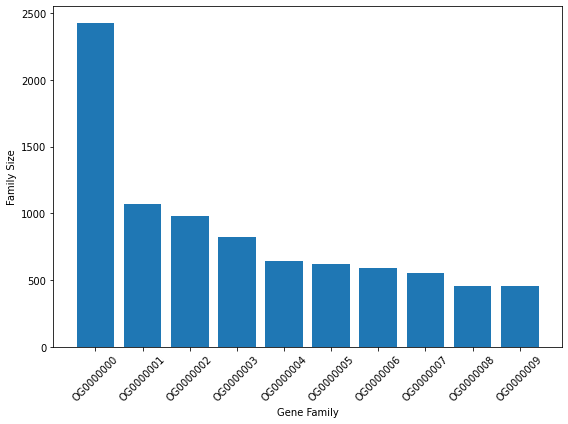

In [13]:
plt.figure(figsize=(8,6))
plt.bar(top_gene_families['Orthogroup'], top_gene_families[species_of_interest[1] + '_Family_Size'])
plt.xlabel('Gene Family')
plt.ylabel('Family Size')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
drop_columns = [1,2,3]
orthos_w_familySize = sorted_orthogroups.drop(columns = sorted_orthogroups.columns[drop_columns])

In [ ]:
orthos_w_familySize.tail(50)

# Looking for interesting genes

In [16]:
row_index = 1
column_name = 'Hglaberrima.2023.pep_Genes'

genes = orthos_w_familySize.loc[row_index, column_name]
print(genes)

['AGRIN_jg2322.t1', ' BMI1A_jg43079.t1', ' EAF6_jg21451.t1', ' GFRP_jg5734.t1', ' LIN1_jg15318.t1', ' MCPI_jg2322.t2', ' NIPLB_jg14865.t1', ' PIF7_jg55942.t1', ' PLPP5_jg8964.t1', ' PO11_jg1006.t1', ' PO11_jg14233.t1', ' PO11_jg15256.t1', ' PO11_jg15299.t1', ' PO11_jg16096.t1', ' PO11_jg16216.t1', ' PO11_jg16387.t1', ' PO11_jg16389.t1', ' PO11_jg16393.t1', ' PO11_jg16555.t1', ' PO11_jg16598.t1', ' PO11_jg16931.t1', ' PO11_jg16980.t1', ' PO11_jg17192.t1', ' PO11_jg18079.t1', ' PO11_jg19345.t1', ' PO11_jg19918.t1', ' PO11_jg2047.t1', ' PO11_jg22413.t1', ' PO11_jg22417.t1', ' PO11_jg22516.t1', ' PO11_jg27967.t1', ' PO11_jg30066.t1', ' PO11_jg32266.t1', ' PO11_jg35697.t1', ' PO11_jg36175.t1', ' PO11_jg36273.t1', ' PO11_jg36839.t1', ' PO11_jg37109.t1', ' PO11_jg37207.t1', ' PO11_jg37680.t1', ' PO11_jg37687.t1', ' PO11_jg37718.t1', ' PO11_jg37813.t1', ' PO11_jg37835.t1', ' PO11_jg37891.t1', ' PO11_jg37899.t1', ' PO11_jg38076.t1', ' PO11_jg38298.t1', ' PO11_jg38380.t1', ' PO11_jg38657.t1', ' 

In [18]:
fam_size_threshold = 2
column_name = 'Hglaberrima.2023.pep_Family_Size'

hglab_family_subset = orthos_w_familySize[orthos_w_familySize[column_name] >= fam_size_threshold]

In [19]:
hglab_family_subset.tail(50)

,Orthogroup,Dmelanogaster.pep_Genes,Dmelanogaster.pep_Family_Size,Hglaberrima.2023.pep_Genes,Hglaberrima.2023.pep_Family_Size,Mmusculus.pep_Genes,Mmusculus.pep_Family_Size
3173,OG0003173,[sp|Q9W517|WAPL_DROME Protein wings apart-like...,2,"[WAPL_jg27293.t1, WAPL_jg27294.t1]",2,[sp|Q65Z40|WAPL_MOUSE Wings apart-like protein...,1
12173,OG0012173,NaN,0,"[jg4434.t1, jg4434.t2]",2,NaN,0
12587,OG0012587,NaN,0,"[jg57829.t1, jg57829.t2]",2,NaN,0
3164,OG0003164,[sp|Q9W0P5|GALE_DROME UDP-glucose 4-epimerase ...,2,"[GALE_52346_t, GALE_jg22779.t1]",2,[sp|Q8R059|GALE_MOUSE UDP-glucose 4-epimerase ...,1
12694,OG0012694,NaN,0,"[jg11006.t1, jg11006.t2]",2,NaN,0
12585,OG0012585,NaN,0,"[C1QT4_45018_t, C1QT4_jg56387.t1]",2,NaN,0
12685,OG0012685,NaN,0,"[SC5A6_jg10785.t1, SC5A6_jg10785.t2]",2,NaN,0
3021,OG0003021,[sp|Q27571|NOS_DROME Nitric oxide synthase OS=...,1,"[NOS1_jg17355.t1, jg17111.t1]",2,[sp|P70313|NOS3_MOUSE Nitric oxide synthase_ e...,2
12684,OG0012684,NaN,0,"[jg11107.t1, jg51499.t1]",2,NaN,0
12582,OG0012582,NaN,0,"[RH2A_jg31511.t1, jg56613.t1]",2,NaN,0


In [20]:
hglab_family_subset2 = hglab_family_subset[(hglab_family_subset['Dmelanogaster.pep_Family_Size'] != 0) & (hglab_family_subset['Mmusculus.pep_Family_Size'] != 0)]

In [ ]:
hglab_family_subset2.tail(50)

In [22]:
len(hglab_family_subset2.index)

1245

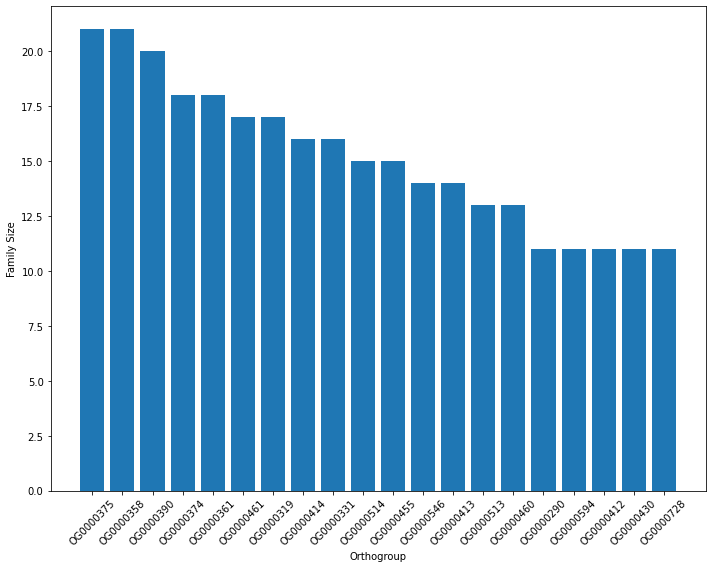

In [30]:
plt.figure(figsize=(10,8))
plt.bar(hglab_family_subset2.iloc[15:35]['Orthogroup'], hglab_family_subset2.iloc[15:35][species_of_interest[1] + '_Family_Size'])
plt.xlabel('Orthogroup')
plt.ylabel('Family Size')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
import numpy as np

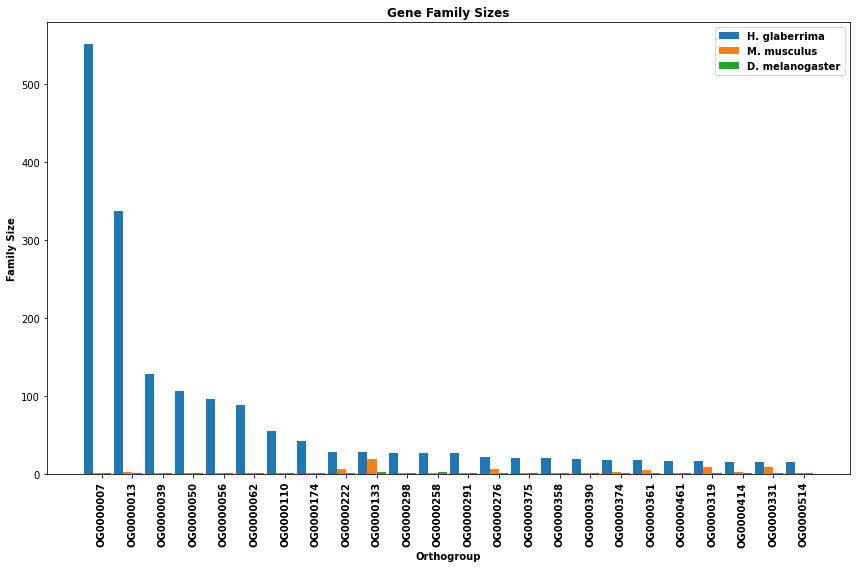

In [215]:

subset_data = hglab_family_subset2.iloc[1:25]
x_values = subset_data['Orthogroup']
columns_of_interest = [species_of_interest[1] + '_Family_Size', species_of_interest[2] + '_Family_Size', species_of_interest[0] + '_Family_Size']

# Calculate the width for each bar
bar_width = 0.3
num_bars = len(columns_of_interest)
total_width = bar_width * num_bars
offset = np.arange(len(x_values))

# Set the figure size
fig, ax = plt.subplots(figsize=(12, 8))  # Adjust the width and height as desired

for i, column in enumerate(columns_of_interest):
    y_values = subset_data[column]
    ax.bar(offset + i * bar_width, y_values, width=bar_width, label=column)

ax.set_xlabel('Orthogroup', fontweight='bold')
ax.set_ylabel('Family Size', fontweight='bold')
ax.set_title('Gene Family Sizes', fontweight='bold')
ax.set_xticks(offset + total_width / 2)
ax.set_xticklabels(x_values, rotation=90, fontweight='bold')
# Set custom legend names
legend_names = ['H. glaberrima', 'M. musculus', 'D. melanogaster']  # Modify the names as desired
ax.legend(legend_names, prop={'weight': 'bold'})
plt.tight_layout()
plt.show()


In [226]:
# Set display options to show all columns
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.expand_frame_repr', False)  # Disable column wrapping
pd.set_option('display.max_colwidth', None)

print(hglab_family_subset2.iloc[0:25])

    Orthogroup                                                                                                                                                                                                                                                                                                                                                                                                             Dmelanogaster.pep_Genes  Dmelanogaster.pep_Family_Size                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

## Function to get amino acid sequences from orthofinder orthogroups for my species of interest.

In [98]:
from Bio import SeqIO

def extract_fasta_sequences(orthogroup_id, column_name, fasta_file):
    # Retrieve the gene IDs for the given Orthogroup ID from the specified column
    gene_ids = df.loc[df['Orthogroup'] == orthogroup_id, column_name].tolist()[0]

    # Split the gene IDs into individual IDs
    #gene_ids = [gene_id.strip() for gene_id in gene_ids.split(',')]

    # Remove leading and trailing white spaces from gene IDs
    gene_ids = [gene_id.strip() for gene_id in gene_ids]

    # Initialize variables for matches and mismatches
    matches = 0
    mismatches = 0

    sequences = []

    # Iterate over the fasta file and extract sequences with matching gene IDs
    for record in SeqIO.parse(fasta_file, 'fasta'):
        if record.id in gene_ids:
            sequences.append(record)
            matches += 1
        else:
            mismatches += 1

    # Write the extracted sequences to a new fasta file named after the Orthogroup ID
    output_file = f"{orthogroup_id}_{column_name}.fasta"
    SeqIO.write(sequences, output_file, 'fasta')

    # Print the gene IDs for the specific Orthogroup and column of interest
    print(f"Gene IDs for Orthogroup {orthogroup_id} and column {column_name} ({len(gene_ids)} identified):")
    for gene_id in gene_ids:
        print(gene_id)

    # Print the matching system statistics
    print(f"Matches: {matches}")
    print(f"Mismatches: {mismatches}")

    # Check if the fasta file resulted in empty sequences
    if len(sequences) == 0:
        raise ValueError("No sequences found for the provided gene IDs.")


In [225]:
#Usage:
df = hglab_family_subset2  # pandas DataFrame containing Orthogroup IDs and gene columns
fasta_file = './00-FASTA-FILES/braker.mod.aa.fa'  # Path to the input fasta file

# Specify the Orthogroup ID and column name for gene IDs extraction
orthogroup_id = 'OG0000007'
column_name = species_of_interest[1] + '_Genes'

extract_fasta_sequences(orthogroup_id, column_name, fasta_file)

Gene IDs for Orthogroup OG0000007 and column Hglaberrima.2023.pep_Genes (552 identified):
CAD23_jg27576.t1
CFA58_jg8841.t1
CPP2_jg43911.t1
DCAF8_jg47791.t1
DYHC_jg21521.t1
GATM_jg57859.t1
HYAL_jg52298.t1
LIN1_jg12089.t1
LIN1_jg23413.t1
LIN1_jg52358.t1
PYGO2_jg14918.t1
PYGO2_jg21836.t1
PYGO2_jg6748.t1
RTBS_jg11666.t1
RTBS_jg11823.t1
RTBS_jg13388.t1
RTBS_jg14919.t1
RTBS_jg17319.t1
RTBS_jg21503.t1
RTBS_jg2561.t1
RTBS_jg26092.t1
RTBS_jg32209.t1
RTBS_jg40690.t1
RTBS_jg41196.t1
RTBS_jg42720.t1
RTBS_jg46849.t1
RTBS_jg50505.t1
RTBS_jg51699.t1
RTBS_jg53711.t1
RTBS_jg56380.t1
RTBS_jg57019.t1
RTBS_jg57626.t1
RTBS_jg57903.t1
RTBS_jg59508.t1
RTBS_jg7440.t1
RTBS_jg8366.t1
RTBS_jg8730.t1
RTJK_jg10057.t1
RTJK_jg10131.t1
RTJK_jg1031.t1
RTJK_jg10657.t1
RTJK_jg11011.t1
RTJK_jg11253.t1
RTJK_jg11657.t1
RTJK_jg11667.t1
RTJK_jg1171.t1
RTJK_jg11786.t1
RTJK_jg11822.t1
RTJK_jg12081.t1
RTJK_jg12090.t1
RTJK_jg12206.t1
RTJK_jg12282.t1
RTJK_jg12345.t1
RTJK_jg12360.t1
RTJK_jg12463.t1
RTJK_jg12603.t1
RTJK_jg12619.t1
